# **12. Introducción a Deep Learning**

**ATENCION**: Hay varios apartados que les falta pulido estos estan marcados con la palabra ''REVISAR'' en el titulo del apartado.

## **12.1. Una simple neurona (Introducción)**

### **12.1.1. ¿Que es Deep Learning?**
Es un enfoque de aprendizaje profundo (Machine Learning) el cual utiliza varias capas de computación profunda. Estas capas son las que permiten al Deep Learning a resolver problemas más complejos.

Gracias a su poder y escalibilidad las **redes neuronales** se han convertido en el modelo de definición de Deep Learning. Las redes neuronales estan compuestas de neuronas, de las cuales cada neurona individualmente realiza una sola operación de computación, el poder de la neurona proviene de la complejidad de las conexiones que se pueden hacer entre ellas.

### **12.1.2. La unidad lineal**
La forma más basica que hay en Deep Learning es la neurona que se representa de la siguiente forma:

![imagen](./images/deepLearningNeuronaTabla.png)<br>
<ins>*La Unidad Lineal: y = wx + b*</ins>

La entrada es *x*. Su conexión con la neurona tiene un peso (weight) *w*. Cada vez que un valor fluye a través de una conexión, se multiplica dicho valor por el peso de la conexión. Para la entrada x, lo que llega a la neurona es w * x. Una red neuronal ''aprende'' modificando sus pesos.

La *b* es un tipo especial de peso que denominamos ''sesgo'' (bias). El sesgo no tiene asociados datos de entrada; en su lugar, colocamos un 1 en el diagrama para que el valor que llega a la neurona sea simplemente b (ya que 1 * b = b). El sesgo permite a la neurona modificar la salida independientemente de sus entradas.

La *y* es el valor que la neurona emite finalmente. Para obtener la salida, la neurona suma todos los valores que recibe a través de sus conexiones. La activación de esta neurona es `y = w * x + b`, o, en forma de fórmula, `y = wx + b.` La formula `y = wx + b` es la ecuación de una recta.

#### **12.1.2.1. Ejemplo - de la Unidad lineal**
Ya que las neuronas individuales suelen funcionar como parte de una red más larga, es util empezar con una neurona simple como modelo como ejemplo. Los modelos de neuronas simples son modelos lineales.

Por ejemplo usando una base de datos que contiene información sobre cereales, se puede entrenar un modelo con el dato de entrada (input) ''sugar'' (azucar), y ''calorias'' (calories) como un resultado (output), tambien suponemos que el sesgo (bias) es de `b=90` y el peso (weight) es de `w=2.5`. Asi que se puede estimar que el contenido caoliro de un cereal con 5 gramos de azucar es: 

![imagen](./images/unidadLinealTablaEjemplo.png)<br>
<ins>*Operando con la unidad lineal*</ins>

Y usando la formula de las calorias, se puede observar que tengo `calorias = 2.5 x 5 + 90 = 102.5`, igual que el resultado dado por la neurona.

### **12.1.3. Multiples entradas**
Utilizando la base de datos del apartado anterior podemos ver que el conjunto de datos ''80 Cereals'' tiene muchas más características además de los ''azúcares''. ¿Y si quisiéramos ampliar nuestro modelo para incluir aspectos como el contenido en fibra o en proteínas? Es bastante sencillo. Solo tenemos que añadir más conexiones de entrada a la neurona, una por cada característica adicional. Para calcular la salida, multiplicaríamos cada entrada por el peso de su conexión y, a continuación, sumaríamos todos los resultados.

![](./images/neuronaConMultiplesEntradasTabla.png)<br>
<ins>*Una unidad lineal con tres datos de entrada.*</ins>

La formula de la neurona seria $y = w_0x_0 + w_1x_1 + w_2x_2 + b$. Una unidad lineal con dos datos de entrada los cuales llenan un plano, y una unidad con muchas entradas de las que se pueden introducir en un hiper plano.

### **12.1.4. Creacion de una neurona con multiples datos de entrada con keras**

In [2]:
from tensorflow import keras
from tensorflow.keras import layers

# Create a network with 1 linear unit
model = keras.Sequential([
    layers.Dense(units=1, input_shape=[3])
])

## **12.2. Redes neuronales profundas (Deep Neural Networks**)
En esta parte se va a ver como construir una red neuronal capaz de aprender relaciones complejas por las cuales son famosas dichas redes neuronales.

La idea principal es la modularidad que ofrecen estas redes complejas de neuronas desde las unidades funcionales simples.

### **12.2.1. Capas**
Las redes neuronales normalmente se organizan en capas, las cuales junta unidades lineales que tiene en comun un conjunto de datos de entrada, y entonces de aquí se consigue una capa densa.

![](./images/capasRedesNeuronalesProfundasTablas.png) <br>
<ins>*Una capa densa con dos unidades lineales las cuales reciben dos datos de entrada y un sesgo.*</ins>

Se puede pensar que cada capa de la red neuronal esta realizando algun tipo de cambio/transformación simple. En un conjunto de capas profundas, una red neuronal puede tranformar sus datos de entrada en operaciones mucho más complejas. En una red neuronal bien entrenada, cada capa es una transformación que te acerca al resultado final.

>**Muchos tipos de capas**<br>Una ''capa'' en Keras es un concepto muy general. Una capa puede ser, en esencia, cualquier tipo de transformación de datos. Muchas capas, como las convolucionales y las recurrentes, transforman los datos mediante el uso de neuronas y se diferencian principalmente en el patrón de conexiones que forman.

### **12.2.2. La función de activación**
Acontece que dos capas densas sin nada de por medio, no son mejores que una capa densa sola. Las capas densas por si solas nunca van a poder sacarnos del mundo de las lineas y los planos, por lo tanto lo que necesitamos es algo *no lineal*, para eso se utilizan las funciones de activación.

![](./images/funcionActivacionTabla.png)<br>
<ins>*Sin las funciones de activación, las redes neuronales solo pueden aprender relaciones lineales, de forma que para ajustarse a curvas, se necesitan usar funciones de activación.*</ins>

Una función de activación es simplemente una función que se le aplica a la salida de la capa (sus activaciones). La más común es la función rectificadora $max(0,x)$.

![](./images/funcionRectificadoraTabla.png)

La función rectificadora tiene un grafico el cual la linea de la parte negativa es ''rectificada'' a cero. Usando esta función con el resultado de las neuronas se pueden *doblar* los datos, asi consiguiendo funciones diferentes de las funciones lineales.

Cuando se le aplica el rectificador a la unidad lineal, se consigue una **unidad rectificadora lineal** (rectified linear unit) o **ReLU**. por esta razón lo más comun es llamar a la función rectificadora como función ReLU. Aplicando la activación ReLU a la unidad lineal significa que el resultado (output) se convierte en $max(0, w * x + b)$, lo cual en un diagrama se ve de la siguiente forma:

![](./images/neuronaConFuncionReLUTabla.png)<br>
<ins>*Una unidad lineal rectificadora.*</ins>

### **12.2.3. Apilando capas densas**
Una vez que se consigue escapar de la linealidad, se puede hacer uso de lo siguiente:

![](./images/apilacionDeCapasOcultasTabla.png)<br>
<ins>*Una apilación de capas densas las cuales constituyen una red ''totalmente conectada''.*</ins>

Las capas que se encuentran antes de la capa de salida se llaman capas ocultas, ya que nunca se ve el resultado de estas directamente.

Como se puede observar en la imagen anterior la capa final es una unidad lineal, lo cual significa que no contiene una función de activación. Esto hace que sea adecuada para una tarea de regresión, en la cual se esta intentando predecir algun valor numerico albitrario. Pero en otras tareas como claficación de elementos, se puede llegar a requerir una funciones de activación en la salida.

### REVISAR **12.2.4. Construcción de modelos secuenciales**
El modelo secuencial que hemos estado utilizando conecta una lista de capas en orden, de la primera a la última: la primera capa recibe la entrada y la última capa genera la salida. Así se crea el modelo que se muestra en la figura anterior:

In [2]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    # the hidden ReLU layers
    layers.Dense(units=4, activation='relu', input_shape=[2]),
    layers.Dense(units=3, activation='relu'),
    # the linear output layer 
    layers.Dense(units=1),
])

Asegúrate de pasar todas las capas juntas en una lista, como [capa, capa, capa, ...], en lugar de como argumentos separados. Para añadir una función de activación a una capa, basta con indicar su nombre en el argumento ''activación''.

## **12.3. Descenso por gradiente estocástico (Stochastic Gradient Descent (SGD))**
- <ins>*estocástico*</ins>-> perteneciente al azar

Los anteriores dos puntos se ve como se puede crear una red totalmente conectada gracias a las apilaciones de las capas densas. Pero como se puede suponer la red cuando se crea asigna los pesos de forma aleatoria esto significando que la red neuronal no sabe nada por ahora, por lo tanto lo que se va a ver en este punto es como hacer el entrenamiento a dicha red neuronal.

Como todo lo relacionado con empezar a entrenar dentro de aprendizaje profundo (Machine Learning), primero se necesita una set de datos de entrenamiento. Cada ejemplo de los datos de entrenamiento consiste en algunas caracteristicas (los datos de entrada) los cuales se juntan con el objetivo esperado (el resultado). Entrenar una red neuronal significa ajustar los pesos de tal formaq eu se puedan transformar las caracteristicas en el objetivo. Si se consigue entrenar de forma exitosa una red neuronal para hacer eso los pesos deben de representar de alguna forma las relaciones entre las caracteristicas y el objetivo segun como se hayan representado en los datos de entrenamiento.

Y hay que tener dos cosas mas en cuenta a la hora de entrenar una red neuronal, primero se necesita una función de perdidas la cual mida como de buenas son las predicciones que hace la red neuronal y despues se necesita un optimizador el cual le pueda indicar a la red neuronal como cambiar sus pesos.

#### **12.3.1. La función de perdida**
Esta función se encarga de decirle a la red neuronal que problema tiene que resolver, de forma que la función de perdida lo que mide es la diferencia entre el valor verdadero de la función objetivo y el valor que el modelo predice.

Una función de perdida común para los problemas de regresión es el **error del valor absoluto medio** (mean absolute error) o **MAE**. Para cada predicción `y_pred`, MAE mide la dispariedad del valor verdadero `y_true` mediante una diferencia absoluta `abs(y_true - y_pred)`.

La perdida total de MAE en el conjunto de datos es la media de todas las diferencias absolutas.

![](./images/MAETable.png)<br>
<src>*El error absoluto medio es la longitud media entre la curva ajustada y los puntos de los datos.*</src>

A parte de la MAE, hay otras funciones de perdida las cuales pueden aparecer en problemas de regresion las cuales son el **error cuadratico medio (MSE)** o la **perdida de Huber**.

Durante el entrenamiento, el modelo usara la función de perdida como guia para encontrar los valores correcto a los pesos (más bajo es mejor). Es decir que la función de perdida le dice a la red neuronal su objetivo.

#### **12.3.2. El optimizador - el descenso del gradiente estocástico**
El optimizador se encarga de decirle a la red neuronal como resolver el problema, ya que este es un algoritmo el cual ajusta el valor de los pesos para minimizar la pérdida.

Virtualmente todos los algoritmos usados en Deep Learning pertenecen a la famlia llamada **descenso del gradiente estocástico**. Son algoritmos iterativoslos cuales entrenan las redes neuronales en pasos, por ejemplo un paso de entrenamiento seria algo asi:
1.  Selecciona una muestra de datos de entrenamiento y procesa esa muestra a través de la red para realizar predicciones.
2. Mide la pérdida entre las predicciones y los valores reales.
3. Por último, ajusta los pesos en la dirección que reduzca la pérdida.

Entonces se realiza de forma iterativa una y otra vez hasta que la pérdida es tan pequeña como se necesite o hasta que no decremente más la pérdida.

![](./images/optimizadorDelGradienteGIF.gif)<br>
<ins>*Entrenamineto de una red neuronal con un descenso del gradiente estocástico.*</ins>

Cada ejemplo de una iteración de datos de entrenamientoses llamado **mini lote (minibatch)** (a veces tambien se le llama solo ''lote'' (batch)), mientras que una ronda completa de datos de entrenamiento es llamado **época (epoch)**. El número de épocas durante las que se realiza el entrenamiento corresponde al número de veces que la red verá cada ejemplo de entrenamiento.

La animación muestra el modelo lineal de la Lección 1 entrenándose con SGD. Los puntos de color rojo pálido representan el conjunto de entrenamiento completo, mientras que los puntos rojos sólidos son los minilotes. Cada vez que el SGD procesa un nuevo minilote, ajusta los pesos (w, la pendiente, y b, la ordenada en el origen) hacia sus valores correctos para ese lote. Lote tras lote, la línea acaba convergiendo hacia su mejor ajuste. Se puede observar que la pérdida se reduce a medida que los pesos se acercan a sus valores reales.

### **12.3.3. Ratio de aprendizaje y tamaño de lotes**
Hay que notar que la linea solo hace un pequeño ajuste en la dirección de cada lote (en vez de moverse directamente a la solución). El tamaño de estos ajustes viene determinado por el **ratio de aprendizaje**. Un ratio de aprendizaje menor significa que la red neuronal necesita ver más mini lotes antes de que sus pesos converjan hacia sus mejores valores.

El ratio de aprendizaje y el tamaño de los minlotes son dos parametros los cuales tiene el mayor impacto en como el proceso de entrenamiento SGD procede. Su interacción normalmente es sutil y la repuesta correcta para dichos parametros muchas veces no es obvia.

Afortunadamente, en la mayoría de los casos no será necesario realizar una búsqueda exhaustiva de hiperparámetros para obtener resultados satisfactorios. **Adam** es un algoritmo SGD que cuenta con una tasa de aprendizaje adaptativa, lo que lo hace adecuado para la mayoría de los problemas sin necesidad de ajustar ningún parámetro (en cierto sentido, se ''autoajusta''). Adam es un excelente optimizador de uso general.

### **12.3.4. Añadiendo la perdida y el optimizador**
Despues de definir el modelo, se puede añadir la furncion de perdida y el optimizador con el método de compilacion del modelo:

```Python
model.compile(
    optimizer="adam",
    loss="mae",
)
```

Notesé en que se puede especificar la función de pérdida y el optimizador con solo una cadena de caracteres. También se puede acceder a ellos directamente a través de la API de Keras *por ejemplo, si se quisiera ajustar los parámetros**, pero en nuestro caso los valores por defecto funcionarán perfectamente.

>**¿Qué hay en un nombre?** <br> El gradiente es un vector que nos indica en qué dirección deben moverse los pesos. Más concretamente, nos indica cómo modificar los pesos para que la pérdida cambie lo más rápido posible. Llamamos a nuestro proceso ''descenso por gradiente'' porque utiliza el gradiente para descender por la curva de pérdida hacia un mínimo. ''Estocástico'' significa ''determinado por el azar''. Nuestro entrenamiento es estocástico porque los minilotes son muestras aleatorias del conjunto de datos. ¡Y por eso se llama SGD!

### REVISAR **12.3.5. Ejemplo - Calidad del vino tinto**
Ahora ya sabemos todo lo necesario para empezar a entrenar modelos de aprendizaje profundo. ¡Veamos cómo funciona en la práctica! Utilizaremos el conjunto de datos ''Red Wine Quality''.

Este conjunto de datos está compuesto por mediciones fisicoquímicas de unos 1.600 vinos tintos portugueses. También incluye una valoración de la calidad de cada vino obtenida a partir de catas a ciegas. ¿Hasta qué punto podemos predecir la calidad percibida de un vino a partir de estas mediciones?

Hemos incluido toda la preparación de los datos en la siguiente celda oculta. No es imprescindible para lo que viene a continuación, así que no dudes en saltártela. Sin embargo, algo que quizá te llame la atención por ahora es que hemos reescalado cada característica para que se sitúe en el intervalo [0,1]. Como veremos con más detalle en la lección 5, las redes neuronales suelen ofrecer mejores resultados cuando sus entradas se encuentran en una escala común.

In [4]:
import pandas as pd
from IPython.display import display

red_wine = pd.read_csv('./red-wine.csv')

# Create training and validation splits
df_train = red_wine.sample(frac=0.7, random_state=0)
df_valid = red_wine.drop(df_train.index)
display(df_train.head(4))

# Scale to [0, 1]
max_ = df_train.max(axis=0)
min_ = df_train.min(axis=0)
df_train = (df_train - min_) / (max_ - min_)
df_valid = (df_valid - min_) / (max_ - min_)

# Split features and target
X_train = df_train.drop('quality', axis=1)
X_valid = df_valid.drop('quality', axis=1)
y_train = df_train['quality']
y_valid = df_valid['quality']



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1109,10.8,0.470,0.43,2.10,0.171,27.0,66.0,0.99820,3.17,0.76,10.8,6
1032,8.1,0.820,0.00,4.10,0.095,5.0,14.0,0.99854,3.36,0.53,9.6,5
1002,9.1,0.290,0.33,2.05,0.063,13.0,27.0,0.99516,3.26,0.84,11.7,7
487,10.2,0.645,0.36,1.80,0.053,5.0,14.0,0.99820,3.17,0.42,10.0,6


¿Cuántas entradas debería tener esta red? Podemos averiguarlo fijándonos en el número de columnas de la matriz de datos. Asegúrate de no incluir aquí la variable de destino (''calidad''); solo las características de entrada.

In [7]:
print(X_train.shape)

(1119, 11)


Once columnas significan once entradas.

Hemos elegido una red de tres capas con más de 1.500 neuronas. Esta red debería ser capaz de aprender relaciones bastante complejas en los datos.

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=[11]),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(1),
])

La elección de la arquitectura de tu modelo debe formar parte de un proceso. Empieza por algo sencillo y utilice la pérdida de validación como guía. Aprenderás más sobre el desarrollo de modelos en los ejercicios.

Una vez definido el modelo, incorporamos el optimizador y la función de pérdida.

In [11]:
model.compile(
    optimizer='adam',
    loss='mae',
)

¡Ya estamos listos para empezar el entrenamiento! Le hemos indicado a Keras que envíe al optimizador 256 filas de los datos de entrenamiento cada vez (el ''batch_size'') y que repita este proceso 10 veces a lo largo de todo el conjunto de datos (las ''epocas'').


In [13]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=256,
    epochs=10,
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.1011 - val_loss: 0.1030
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0989 - val_loss: 0.0985
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0980 - val_loss: 0.0984
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0967 - val_loss: 0.0994
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0956 - val_loss: 0.0991
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0940 - val_loss: 0.0979
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0953 - val_loss: 0.0950
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0946 - val_loss: 0.0983
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0967 - val_loss: 0.0978
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0961 - val_loss: 0.1044


Como puedes ver, Keras te mantendrá informado sobre la pérdida a medida que se entrena el modelo.

Sin embargo, a menudo la mejor forma de visualizar la pérdida es representarla gráficamente. De hecho, el método `fit` guarda un registro de la pérdida generada durante el entrenamiento en un objeto `History`. Convertiremos los datos a un dataframe de Pandas, lo que facilita la representación gráfica.

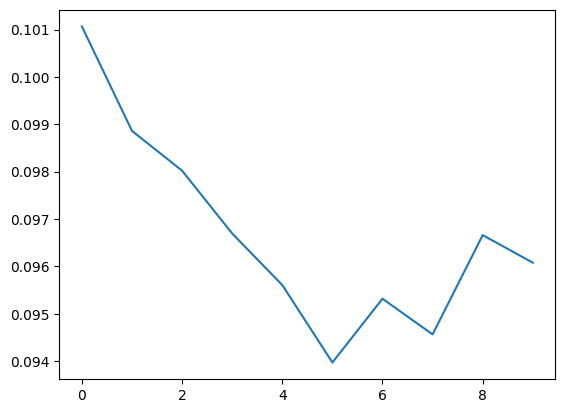

In [15]:
import pandas as pd

# convert the training history to a dataframe
history_df = pd.DataFrame(history.history)
# use Pandas native plot method
history_df['loss'].plot();

Fíjate en cómo la pérdida se estabiliza a medida que pasan las épocas. Cuando la curva de pérdida se vuelve horizontal como se ve aquí, significa que el modelo ha aprendido todo lo que podía y que no habría motivo para continuar con épocas adicionales.

## **12.4. Sobreajuste y subajuste (Overfitting and Underfitting)**
En este apartado se va a explicar como interpretar las curvas de aprendizaje y como usarlas para guiar al modelo durante el entrenamiento.

### **12.4.1. Interpretando las curvas de aprendizaje**
Se puede agrupar la información de los modelos de aprendizaje en dos grupos **señal (signal)** y **ruido (noise)**. La *señal* es la parte que generaliza, es decir es la parte que ayuda al modelo a hacer predicciones desde nuevos datos. El *ruido* es la unica parte que es verdadera a los datos de entrenamiento, este son fluctionaciones aleatorias que vienen de los datos del mundo real o de los patrones no informativos de forma accidental estos son los que no ayudan a hacer predicciones en el modelo. Es decir el ruido es la parte que se ve util pero no lo es.

Se entrena un modelo eligiendo los pesos de los parámetros para minimizar la perdida de los datos de entrenamiento. Como se sabe para evaluar el rendimiento del modelo, hay que evaluarlo desde un nuevo grupo de datos, los datos de validación.

En la siguiente imagen se puede observar la el trazado de la perdida de época en época (epoch by epoch), A esto se le añade el trazado de los datos de validación, estos trazados se les llaman **curvas de aprendizaje**, que para entrenar un modelo en el Deep Learning de forma efectiva necesitamos ser capaces de interpretarlos.

![](./images/curvasAprendizajeSobreajusteSubajusteTabla.png)<br>
<ins>*La validación de la perdida provee un valor estimado del error esperado de los datos no vistos.*</ins>

Teniendo esto en cuenta la perdida del aprendizaje bajara cuando el modelo aprenda la señal o cuando aprenda el ruido. Pero la perdida de los datos de validación caerá solo cuando el modelo aprenda la señal (Hay que tener en cuanta que que todo el ruido que haya aprendido el modelo de los datos de aprendizaje no los podra usar para generar nuevos datos). Asi que cuando el modelo ha aprendido la señal ambas curvas bajan, pero cuando aprende el ruido se crea una brecha en las curvas, y dicho tamaño de la brecha dice cuanto ruido el modelo ha aprendido.

Lo ideal sería crear modelos que aprendieran toda la señal y nada del ruido. Esto prácticamente nunca ocurrirá. En su lugar, hacemos una concesión. Podemos conseguir que el modelo aprenda más señal a costa de aprender más ruido. Mientras la concesión nos resulte favorable, la pérdida de validación seguirá disminuyendo. Sin embargo, a partir de cierto punto, la concesión puede volverse en nuestra contra, el coste supera al beneficio y la pérdida de validación comienza a aumentar.

![](./images/curvasAprendizajeSobreajusteSubajusteTabla2.png)

Esta disyuntiva indica que pueden surgir dos problemas al entrenar un modelo: falta de señal o exceso de ruido. El **subajuste** del conjunto de entrenamiento se produce cuando la pérdida no es tan baja como podría ser porque el modelo no ha aprendido suficiente señal. El **sobreajuste** del conjunto de entrenamiento se produce cuando la pérdida no es tan baja como podría ser porque el modelo ha aprendido demasiado ruido. La clave para entrenar modelos de aprendizaje profundo consiste en encontrar el mejor equilibrio entre ambos.

### **12.4.2. Capacidad**
La capacidad del modelo hace referencia a el tamaño y la complejidad de los patrones que es capaz de aprender. Para las redes neuronales, esto es determinado por la cantidad de neuronas que tiene y como estan conectadas entre ellas. Si parece que la red neuronal ajusta de forma ineficiente los datos, se deberia de tratar de incrementar la capacidad.

Se puede incrementar la capacidad de la red neuronal o bien haciendo que sea mas ancha (wider) (más unidades existen en las capas), o haciendola más profunda (añadiendo mas capas). Redes mas anchas tiene una facilidad para aprender relaciones lineales, mientras que las redes profundas prefieren las no lineales. La mejor entre estas depende de los datos que se le introduzcan a la red neuronal.

De la siguiente forma se ve como se puede hacer esto en keras (tensorflow):
```Python
model = keras.Sequential([
    layers.Dense(16, activation='relu'),
    layers.Dense(1),
])

wider = keras.Sequential([
    layers.Dense(32, activation='relu'),
    layers.Dense(1),
])

deeper = keras.Sequential([
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1),
])
```

### **12.4.3.Parada temprana (Early Stopping)**
Como se ha mencionado antes el modelo aprede ruido con relativa facilidad, la perdida en la validación puede emepzar a incrementar durante el entrenamiento. Para prevenir esto, simplemente se puede para el entrenamiento cuando parece que la perdida por validación no esta disminuyendo más. Interrumpir el entrenamineto de esta manera es llamado **parada temprana (early stopping)**.

![](./images/earlyStopingTable.png)<br>
<ins>*Se mantiene el modelo donde la perdida por validación esta en su mínimo.*</ins>

Una vez se ha detectado que la perdida en la validación esta incrementando de nuevo, se pueden restablecer los pesos al valor que tenian cuando ocurrio el mínimo en la perdida. Esta asegura que el modelo no va a continuar aprendiendo el ruido y sobreajustando los datos.

El entrenamiento con la parada temprana también significa que se corre menos riesgo de detener el entrenamiento demasiado pronto, antes de que la red neuronal haya terminado de aprender la señal. Así pues, además de evitar el sobreajuste que se produce al entrenar durante demasiado tiempo, la parada temprana también puede evitar el subajuste que se produce al no entrenar lo suficiente. Solo se tiene que establecer el número de épocas de entrenamiento en una cifra elevada (más de las que necesitarás) y la parada temprana se encargará del resto.


#### REVISAR **12.4.3.1. Añadiendo parada temprana (early stopping)**
En Keras, incorporamos la detención temprana en nuestro entrenamiento mediante una función de llamada de retorno. Una función de llamada de retorno es simplemente una función que se quiere ejecutar de vez en cuando mientras se entrena la red. La función de llamada de retorno de detención temprana se ejecutará después de cada época. (Keras cuenta con una variedad de funciones de llamada de retorno útiles predefinidas, pero también puedes definir las tuyas propias).

In [4]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=20, # how many epochs to wait before stopping
    restore_best_weights=True,
)

Estos parámetros indican: ''Si no se ha producido al menos una mejora de 0,001 en la pérdida de validación con respecto a las 20 épocas anteriores, detén el entrenamiento y conserva el mejor modelo que hayas encontrado''. A veces puede resultar difícil determinar si la pérdida de validación está aumentando debido a un sobreajuste o simplemente a una variación aleatoria del lote. Estos parámetros nos permiten establecer unos márgenes de tolerancia en cuanto al momento de detener el entrenamiento.

Como veremos en nuestro ejemplo, pasaremos esta función de llamada de retorno al método `fit` junto con la pérdida y el optimizador.

### REVISAR **12.4.4. Ejemplo - Entrenamiento de un modelo con parada temprana**
Let's continue developing the model from the example in the last tutorial. We'll increase the capacity of that network but also add an early-stopping callback to prevent overfitting.

Here's the data prep again.

In [6]:
import pandas as pd
from IPython.display import display

red_wine = pd.read_csv('./red-wine.csv')

# Create training and validation splits
df_train = red_wine.sample(frac=0.7, random_state=0)
df_valid = red_wine.drop(df_train.index)
display(df_train.head(4))

# Scale to [0, 1]
max_ = df_train.max(axis=0)
min_ = df_train.min(axis=0)
df_train = (df_train - min_) / (max_ - min_)
df_valid = (df_valid - min_) / (max_ - min_)

# Split features and target
X_train = df_train.drop('quality', axis=1)
X_valid = df_valid.drop('quality', axis=1)
y_train = df_train['quality']
y_valid = df_valid['quality']

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1109,10.8,0.470,0.43,2.10,0.171,27.0,66.0,0.99820,3.17,0.76,10.8,6
1032,8.1,0.820,0.00,4.10,0.095,5.0,14.0,0.99854,3.36,0.53,9.6,5
1002,9.1,0.290,0.33,2.05,0.063,13.0,27.0,0.99516,3.26,0.84,11.7,7
487,10.2,0.645,0.36,1.80,0.053,5.0,14.0,0.99820,3.17,0.42,10.0,6


Now let's increase the capacity of the network. We'll go for a fairly large network, but rely on the callback to halt the training once the validation loss shows signs of increasing.

In [8]:
from tensorflow import keras
from tensorflow.keras import layers, callbacks

early_stopping = callbacks.EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=20, # how many epochs to wait before stopping
    restore_best_weights=True,
)

model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=[11]),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(1),
])
model.compile(
    optimizer='adam',
    loss='mae',
)



After defining the callback, add it as an argument in fit (you can have several, so put it in a list). Choose a large number of epochs when using early stopping, more than you'll need.

Minimum validation loss: 0.09262420237064362


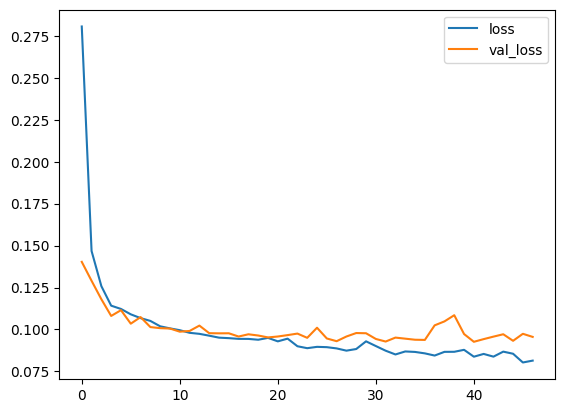

In [9]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=256,
    epochs=500,
    callbacks=[early_stopping], # put your callbacks in a list
    verbose=0,  # turn off training log
)

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot();
print("Minimum validation loss: {}".format(history_df['val_loss'].min()))



And sure enough, Keras stopped the training well before the full 500 epochs!

## **12.5. Normalización por abandono y por lotes (Dropout and Batch Normalization)**
A continuación se van a ver dos tipos de capas especiales, las cuales no contiene ninguna neurona, pero añaden funcionalidad que puede ser beneficiosa para los modelos de varias maneras. Ambas son usualmente usadas en arquitecturas modernas.

### **12.5.1. Abandono (Dropout)**
La primera es la **capa de abandono (dropout layer)** la cual puede ayudar a corregir el sobreajuste.

Como se ha visto en el enterior punto el sobreajuste esta causado por que el modelo aprende patrones malos/falsos de los datos de entrenamiento. Para reconocer estos patrones la red neuronal normalmente depende de una combinación de pesos especifica. Para ser exactos esto hace que sea fragil, ya que si se elimina uno todos caen con el, se le puede llamar una conspiración.

Esta es la idea detras de este **método del abandono**. Para romper estas ''conspiraciones'' se puede eliminar aleatoriamente una fracción de las unidades de entrada de una capa en cada paso del entrenamiento, lo que dificulta mucho más que la red aprenda esos patrones falsos presentes en los datos de entrenamiento. En su lugar, se ve obligada a buscar patrones amplios y generales, cuyos patrones de pesos suelen ser más robustos.

![](./images/dropoutDeepLearningTable.gif)<br>
<ins>*Aquí se puede observar que el 50% del abandono ha sido añadido entre las dos capas ocultas.*</ins>

También se puede intrepretar el abandono como la creación de algun tipo de conjunto de redes. Las predicciones no las va a realizar una gran red neuronal, si no que por un comite de pequeñas neuronas. Ya que los miembros del comité tienden a realizar distintos tipos de errores, pero al mismo tiempo aciertan, lo que hace que el comité en su conjunto sea mejor que cualquier individuo solo. 

#### **12.5.1.1. Añadir abandono en una red neuronal**
En Keras, el argumento `rate` de la tasa de dropout define qué porcentaje de unidades de entrada se deben desactivar. Coloca la capa de dropout justo antes de la capa a la que quieras aplicar el dropout:
```Python
keras.Sequential([
    # ...
    layers.Dropout(rate=0.3), # apply 30% dropout to the next layer
    layers.Dense(16),
    # ...
])
```

### **12.5.2. Normalización por lotes**
La **normalización por lotes (batch normalization o batchnorm)**, puede ayudar a corregir el entrenamiento que es lento o inestable.

En el entrenamiento de redes neuronales es común convertir todos los datos a una escala común. La razón es porque el descenso por gradiente estocástico (SGC) va a interncambiar los pesos de la red in propoción a como de larga sea la activación de los datos producidos. Características que tienden a producir activaciones de tamaños muy distintos que pueden crear un comportamiento inestable en el entrenamiento.

Teniendo en cuenta que es bueno normalizar los datos antes de introducirlos en la red neuronal, normalizar dentro de la red neuronal seria mejor. Para eso sirve esta capa, una capa de normalización por lotes comprueba cada lote que se le introduce, al principio normalizando el lote con su propia media y desviación estándr, y despues situando los datos en una nueva escala con dos parámetros de reescalado entrenable. La normalización por lotes, en efecto, lleva a cabo una especie de reescalado coordinado de sus entradas.

Normalmente la normalización por lotes es añadida como una ayuda a la optimización del proceso (aunque algunas veces puede ayudar a la predicción del rendimiento). Los modelos con este tipo de normalización tienden a necesitar menos épocas para completar su entrenamiento. Además este tipo de normalización puede ayudar a resolver varios problemas que pueden hacer que el entrenamiento se que de ''atascado''.

#### **12.5.2.1. Añadir normalización por lotes**
Parece que la normalización por lotes se puede utilizar prácticamente en cualquier punto de una red. Se puede colocar después de una capa...

```Python
layers.Dense(16, activation='relu'),
layers.BatchNormalization(),
```

... o entre una capa y su función de activación:

```Python
layers.Dense(16),
layers.BatchNormalization(),
layers.Activation('relu'),
```

Y si la añades como primera capa de tu red, puede actuar como una especie de preprocesador adaptativo, sustituyendo a algo parecido al StandardScaler de Sci-Kit Learn.

### REVISAR **12.5.3. Ejemplo - Usando normalización en lotes y por abandono**
Let's continue developing the Red Wine model. Now we'll increase the capacity even more, but add dropout to control overfitting and batch normalization to speed up optimization. This time, we'll also leave off standardizing the data, to demonstrate how batch normalization can stabalize the training.

In [12]:
# Setup plotting
import matplotlib.pyplot as plt

#plt.style.use('seaborn-whitegrid')
# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)


import pandas as pd
red_wine = pd.read_csv('./red-wine.csv')

# Create training and validation splits
df_train = red_wine.sample(frac=0.7, random_state=0)
df_valid = red_wine.drop(df_train.index)

# Split features and target
X_train = df_train.drop('quality', axis=1)
X_valid = df_valid.drop('quality', axis=1)
y_train = df_train['quality']
y_valid = df_valid['quality']


When adding dropout, you may need to increase the number of units in your Dense layers.

In [13]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(1024, activation='relu', input_shape=[11]),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1),
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


There's nothing to change this time in how we set up the training.

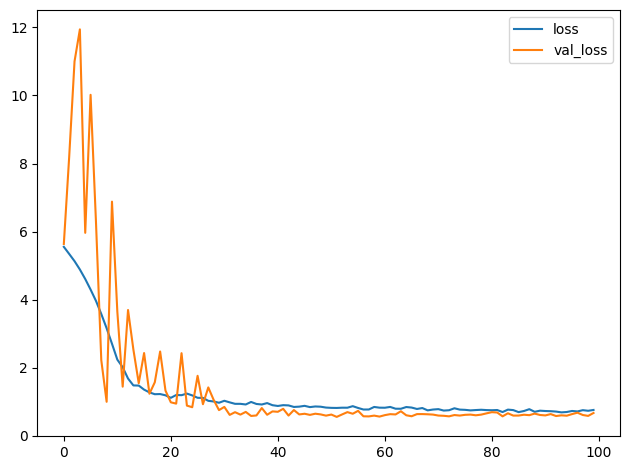

In [14]:
model.compile(
    optimizer='adam',
    loss='mae',
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=256,
    epochs=100,
    verbose=0,
)


# Show the learning curves
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot();

You'll typically get better performance if you standardize your data before using it for training. That we were able to use the raw data at all, however, shows how effective batch normalization can be on more difficult datasets.

## **12.6. Clasificación binaria**
Gracias a la clasificación binaria se puede aplicar para resolver uno de los problemas que tienen el aprendije profundo (deep learning) la clasificación, todo lo que se ha visto con anterioridad sigue siendo igual menos la funcoin de perdida que se usa y el tipo de resultados que se quiere que la capa final produzca.

### **12.6.1.Clasificación binaria**
La clasificación es uno de las dos clases comunes de problemas en el aprendizaje. Se podria requerir que se predijera si un cliente va a realizar una compra, o la va a realizar en metálico o en tarjeta, o incluso si las señales del espacio profundo son evidencias de un nuevo planeta. Estos son problemas para la **clasificación binaria**.

En los datos crudos, las clases pueden estar representadas por cadenas de caracteres como ''Sí'' y ''No'', o ''Perro'' y ''Gato''. Antes de utilizar estos datos, se le asigna una **etiqueta de clase**, una clase tendrá el valor `0` y la otra, el valor `1`. Al asignarles etiquetas numéricas, los datos adquieren un formato que una red neuronal puede utilizar.

### **12.6.2. Precisión y entropía cruzada (Precisión y entropía cruzada)**
La precisión es una de las muchas métricas que se utilizan para medir el éxito en un problema de clasificación. La precisión es la relación entre las predicciones correctas y el total de predicciones: `precisión = número_correctas / total`. Un modelo que siempre predijera correctamente tendría una puntuación de precisión de `1,0`. En igualdad de condiciones, la precisión es una métrica razonable que se puede utilizar siempre que las clases del conjunto de datos aparezcan con aproximadamente la misma frecuencia.

El problema de la precisión (y de la mayoría de las demás métricas de clasificación) es que no puede utilizarse como función de pérdida. El SGD necesita una función de pérdida que varíe de forma suave, pero la precisión, al ser una relación entre recuentos, varía a «saltos». Por lo tanto, tenemos que elegir un sustituto que actúe como función de pérdida. Este sustituto es la función de entropía cruzada.

Ahora bien, recordemos que la función de pérdida define el objetivo de la red durante el entrenamiento. En la regresión, nuestro objetivo era minimizar la distancia entre el resultado esperado y el resultado predicho. Elegimos el MAE para medir esta distancia.

En la clasificación, lo que buscamos en cambio es una distancia entre probabilidades, y eso es precisamente lo que proporciona la entropía cruzada. La entropía cruzada es una especie de medida de la distancia entre una distribución de probabilidad y otra.

![](./images/entropiaCruzadaTabla.png)<br>
<ins>*La entropía cruzada penaliza predicciones de probabilidades incorrectas.*</ins>

La idea es que queremos que nuestra red prediga la clase correcta con una probabilidad de `1,0`. Cuanto más se aleje la probabilidad predicha de `1,0`, mayor será la pérdida por entropía cruzada.

Las razones técnicas por las que utilizamos la entropía cruzada son un poco sutiles, pero lo más importante que hay que retener de esta sección es precisamente esto: utiliza la entropía cruzada como medida de pérdida para la clasificación; otras métricas que te puedan interesar (como la precisión) tenderán a mejorar junto con ella.

### REVISAR **12.6.3. Realizar probabilidades con la función sigmoide (Sigmoid function)**
Tanto la función de entropía cruzada como la de precisión requieren probabilidades como entradas, es decir, números comprendidos entre 0 y 1. Para convertir las salidas de valor real generadas por una capa densa en probabilidades, aplicamos un nuevo tipo de función de activación: la función de activación sigmoide.

![](./images/sigmoidActivationTable.png)<br>
<ins>*La funcion sigmoide asigna números reales en un intervalo entre $[0, 1]$*</ins>

Para obtener la predicción final de la clase, definimos un umbral de probabilidad. Normalmente, este será 0,5, de modo que al redondear se obtenga la clase correcta: un valor inferior a 0,5 corresponde a la clase con la etiqueta 0, y un valor igual o superior a 0,5 corresponde a la clase con la etiqueta 1. Keras utiliza por defecto un umbral de 0,5 con su métrica de precisión.

### REVISAR **12.6.4. Example - Binary Classification**

Now let's try it out!

The Ionosphere dataset contains features obtained from radar signals focused on the ionosphere layer of the Earth's atmosphere. The task is to determine whether the signal shows the presence of some object, or just empty air.

In [16]:
import pandas as pd
from IPython.display import display

ion = pd.read_csv('./ion.csv', index_col=0)
display(ion.head())

df = ion.copy()
df['Class'] = df['Class'].map({'good': 0, 'bad': 1})

df_train = df.sample(frac=0.7, random_state=0)
df_valid = df.drop(df_train.index)

max_ = df_train.max(axis=0)
min_ = df_train.min(axis=0)

df_train = (df_train - min_) / (max_ - min_)
df_valid = (df_valid - min_) / (max_ - min_)
df_train.dropna(axis=1, inplace=True) # drop the empty feature in column 2
df_valid.dropna(axis=1, inplace=True)

X_train = df_train.drop('Class', axis=1)
X_valid = df_valid.drop('Class', axis=1)
y_train = df_train['Class']
y_valid = df_valid['Class']

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V26,V27,V28,V29,V30,V31,V32,V33,V34,Class
1,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,good
2,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,bad
3,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,good
4,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,bad
5,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,good


We'll define our model just like we did for the regression tasks, with one exception. In the final layer include a 'sigmoid' activation so that the model will produce class probabilities.

In [17]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(4, activation='relu', input_shape=[33]),
    layers.Dense(4, activation='relu'),    
    layers.Dense(1, activation='sigmoid'),
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Add the cross-entropy loss and accuracy metric to the model with its compile method. For two-class problems, be sure to use 'binary' versions. (Problems with more classes will be slightly different.) The Adam optimizer works great for classification too, so we'll stick with it.

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

The model in this particular problem can take quite a few epochs to complete training, so we'll include an early stopping callback for convenience.

In [19]:
early_stopping = keras.callbacks.EarlyStopping(
    patience=10,
    min_delta=0.001,
    restore_best_weights=True,
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=1000,
    callbacks=[early_stopping],
    verbose=0, # hide the output because we have so many epochs
)

VWe'll take a look at the learning curves as always, and also inspect the best values for the loss and accuracy we got on the validation set. (Remember that early stopping will restore the weights to those that got these values.)

Best Validation Loss: 0.3121
Best Validation Accuracy: 0.8857


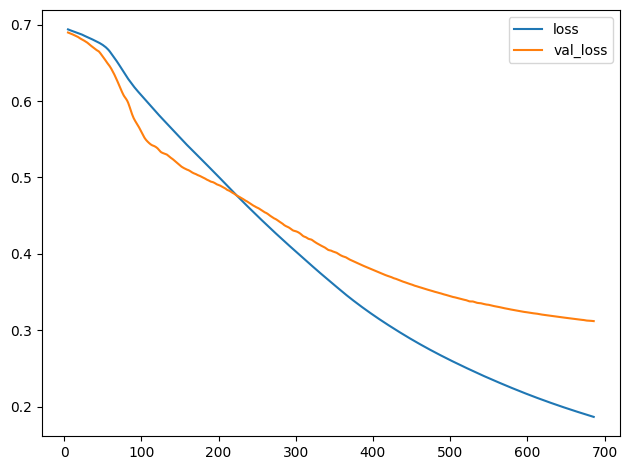

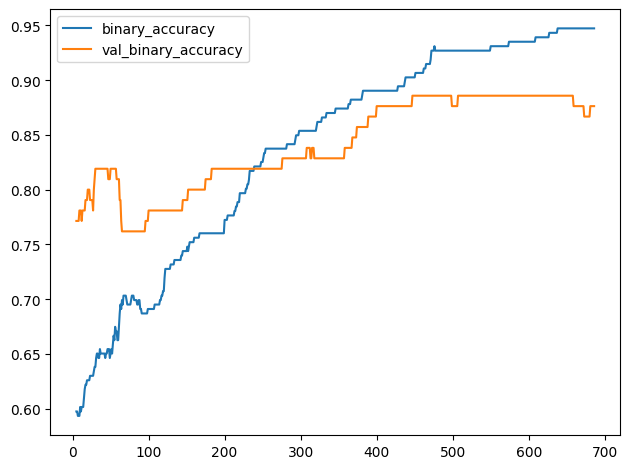

In [20]:
history_df = pd.DataFrame(history.history)
# Start the plot at epoch 5
history_df.loc[5:, ['loss', 'val_loss']].plot()
history_df.loc[5:, ['binary_accuracy', 'val_binary_accuracy']].plot()

print(("Best Validation Loss: {:0.4f}" +\
      "\nBest Validation Accuracy: {:0.4f}")\
      .format(history_df['val_loss'].min(), 
              history_df['val_binary_accuracy'].max()))